# STA272 Test #1: Weeks 1-5

**Test Date:** February 12, 2026
**Total Marks:** 50

## Instructions
- Complete all tasks in order
- Fill in the `...` placeholders in student cells
- Write text responses in interpretation questions
- Show all your work for partial credit
- Use the provided datasets: `movies_modeling.csv` and `brfss_sample_raw.csv`

## Marks Breakdown
- **Part 1:** Data Loading & Manipulation - **9 marks**
  - Task #1: 1 mark
  - Task #2 (a,b,c): 3 marks
  - Task #3 (a,b): 2 marks
  - Task #4 (a,b,c): 3 marks

- **Part 2:** Linear Regression - **12 marks**
  - Question #1 (interpretation): 12 marks

- **Part 3:** Logistic Regression & Trees - **17 marks**
  - Task #5 (a,b,c): 3 marks
  - Task #6 (a,b,c): 3 marks
  - Task #7 (a,b): 2 marks
  - Question #2 (interpretation): 9 marks

- **Part 4:** Synthesis & Comparison - **12 marks**
  - Question #3 (comparison): 12 marks

**Total: 9 + 12 + 17 + 12 = 50 marks**

## PART 1: Data Loading, Exploration & Manipulation

### Task #1: Load and Explore Movie Data (1 mark)

**Dataset:** movies_modeling.csv

**Instructions:** Read `movies_modeling.csv` into a dataframe called `movies_df`. Display the shape and first 5 rows.

In [ ]:
import pandas as pd
import numpy as np

# Read movies_modeling.csv into a dataframe called movies_df
movies_df = pd.read_csv('...')

# Display the shape
print(f"Dataset shape: {movies_df.shape}")

# Display first 5 rows
movies_df.head()

In [1]:
import pandas as pd
import numpy as np

movies_df = pd.read_csv('movies_modeling.csv')
print(f"Dataset shape: {movies_df.shape}")
movies_df.head()

Dataset shape: (5000, 17)


,movie_id,title,revenue,popularity,budget,release_date,runtime,genres,vote_average,production_companies,production_countries,actors,crews,actor_avg_pop,crew_avg_pop,cast_count,crew_count
0,19995,Avatar,2923706026,54.7630,237000000,2009-12-16,162,"Action,Adventure,Fantasy,Science Fiction",7.600,"Dune Entertainment,Lightstorm Entertainment,20...","US,GB","Sam Worthington(6.2), Zoe Saldaña(9.9), Sigour...","John Refoua(0.2), Stephen E. Rivkin(0.2), Terr...",5.91624,1.0789,67,991
1,299534,Avengers: Endgame,2799439100,17.8597,356000000,2019-04-24,181,"Adventure,Science Fiction,Action",8.237,Marvel Studios,US,"Robert Downey Jr.(8.7), Chris Evans(7.2), Mark...","Paul Schneider(0.3), Louis D'Esposito(1.2), Ca...",8.80360,0.4552,107,608
2,76600,Avatar: The Way of Water,2353096253,61.9541,350000000,2022-12-14,192,"Action,Adventure,Science Fiction",7.602,"20th Century Studios,Lightstorm Entertainment,...",US,"Sam Worthington(6.2), Zoe Saldaña(9.9), Sigour...","James Cameron(4.1), James Cameron(4.1), James ...",6.40434,2.5273,57,205
3,597,Titanic,2264162353,27.6669,200000000,1997-12-18,194,"Drama,Romance",7.900,"Paramount Pictures,20th Century Fox,Lightstorm...",US,"Leonardo DiCaprio(9.4), Kate Winslet(6.5), Bil...","James Cameron(4.1), James Horner(0.7), Russell...",4.99382,1.9788,116,262
4,980477,Ne Zha 2,2259822417,42.1851,80000000,2025-01-29,144,"Animation,Fantasy,Adventure,Action",8.123,"Chengdu Coco Cartoon,Beijing Enlight Pictures,...",CN,"Lu Yanting(1.1), Joseph(0.6), Han Mo(1.0), Che...","Jiao Zi(0.6), Jiao Zi(0.6), Liu Wenzhang(0.3),...",0.78002,0.4221,24,10


### Task #2: Data Filtering and Groupby

#### Task #2a: Filter Popular Movies (1 mark)
Filter movies released after 2010 with revenue > $100,000,000 and runtime >= 90 minutes. Store the result in `popular_movies`.

In [ ]:
# Filter movies: after 2010, revenue > 100M, runtime >= 90
popular_movies = movies_df[(movies_df['...'] > ...) &
                           (movies_df['...'] > ...) &
                           (movies_df['...'] >= ...)]

print(f"Number of popular movies: {len(popular_movies)}")

In [2]:
# Filter movies: after 2010, revenue > 100M, runtime >= 90
popular_movies = movies_df[(movies_df['release_date'] > '2010-01-01') &
                           (movies_df['revenue'] > 100000000) &
                           (movies_df['runtime'] >= 90)]

print(f"Number of popular movies: {len(popular_movies)}")

Number of popular movies: 868


#### Task #2b: Create Action Indicator (1 mark)
Create a binary indicator column called `has_action` in `movies_df` (1 if genres contains "Action", 0 otherwise).

In [ ]:
# Create has_action indicator
movies_df['has_action'] = movies_df['genres'].str.contains('...', na=False).astype(...)

In [3]:
# Create has_action indicator
movies_df['has_action'] = movies_df['genres'].str.contains('Action', na=False).astype(int)

#### Task #2c: Groupby Aggregation (1 marks)
Group by `has_action` and calculate mean revenue and count. Store the result in `action_stats`.

In [ ]:
# Groupby has_action
action_stats = movies_df.groupby('...').agg({
    'revenue': ['...', '...']
})
print(action_stats)

In [4]:
# Groupby has_action
action_stats = movies_df.groupby('has_action').agg({
    'revenue': ['mean', 'count']
})
print(action_stats)

                 revenue      
                    mean count
has_action                    
0           1.002277e+08  3451
1           1.793799e+08  1549


### Task #3: Feature Engineering

#### Task #3a: Date Feature Engineering (1 mark)
From `release_date`, create three new columns in `movies_df`:
- `release_year`: Extract year
- `release_decade`: Format as "2010s", "2000s", etc.
- `winter_release`: 1 if month is Dec=12, Jan=1, or Feb=2, else 0

In [ ]:
# Convert to datetime
movies_df['release_date'] = pd.to_datetime(movies_df['...'])

# Extract year and create decade
movies_df['release_year'] = movies_df['release_date'].dt....

# Create a decade label (e.g., "1990s") from each movie's release year; '//' is integer (floor) division, 
# so release_year // 10 drops the last digit (1999 -> 199), then * 10 turns it back into the decade (1990).
movies_df['release_decade'] = (movies_df['release_year'] // 10 * 10).astype(str) + 's'

# Create winter_release indicator
movies_df['winter_release'] = movies_df['release_date'].dt.month.isin([..., ..., ...]).astype(int)

In [5]:
# Convert to datetime
movies_df['release_date'] = pd.to_datetime(movies_df['release_date'])

# Extract year and create decade
movies_df['release_year'] = movies_df['release_date'].dt.year
movies_df['release_decade'] = (movies_df['release_year'] // 10 * 10).astype(str) + 's'

# Create winter_release indicator
movies_df['winter_release'] = movies_df['release_date'].dt.month.isin([12, 1, 2]).astype(int)

#### Task #3b: Regex Feature Extraction (1 mark)
Extract the maximum crew popularity score from the `crews` column using regex pattern `r'\((\d+\.?\d*)\)'`. Store result in `crew_max_pop` column.

In [ ]:
import re

def extract_max_pop(crew_string):
    if pd.isna(crew_string):
        return np.nan
    scores = re.findall(r'...', crew_string)
    if scores:
        return max([float(s) for s in scores])
    return np.nan

movies_df['crew_max_pop'] = movies_df['...'].apply(extract_max_pop)
movies_df[['title', 'crews', 'crew_max_pop']].head()

In [6]:
import re

def extract_max_pop(crew_string):
    if pd.isna(crew_string):
        return np.nan
    scores = re.findall(r'\((\d+\.?\d*)\)', crew_string)
    if scores:
        return max([float(s) for s in scores])
    return np.nan

movies_df['crew_max_pop'] = movies_df['crews'].apply(extract_max_pop)
movies_df[['title', 'crews', 'crew_max_pop']].head()

,title,crews,crew_max_pop
0,Avatar,"John Refoua(0.2), Stephen E. Rivkin(0.2), Terr...",4.1
1,Avengers: Endgame,"Paul Schneider(0.3), Louis D'Esposito(1.2), Ca...",1.2
2,Avatar: The Way of Water,"James Cameron(4.1), James Cameron(4.1), James ...",4.1
3,Titanic,"James Cameron(4.1), James Horner(0.7), Russell...",4.1
4,Ne Zha 2,"Jiao Zi(0.6), Jiao Zi(0.6), Liu Wenzhang(0.3),...",0.6


### Task #4: Fit Linear Regression

#### Task #4a: Data Preparation (1 mark)
Select key variables (revenue as outcome; budget, runtime, vote_average, popularity as predictors) and remove missing values. Store the cleaned dataframe in `movies_clean`.

In [ ]:
key_vars = ['revenue', '...', '...', '...', '...']
movies_clean = movies_df[key_vars].dropna()
print(f"Clean dataset: {len(movies_clean)} rows")

In [7]:
key_vars = ['revenue', 'budget', 'runtime', 'vote_average', 'popularity']
movies_clean = movies_df[key_vars].dropna()
print(f"Clean dataset: {len(movies_clean)} rows")

Clean dataset: 5000 rows


#### Task #4b: Train/Test Split (1 mark)
Split into train (70%) and test (30%) with random_state=123. Store results in `X_train`, `X_test`, `y_train`, `y_test`.

In [ ]:
from sklearn.model_selection import train_test_split

X = movies_clean[['budget', 'runtime', 'vote_average', 'popularity']]
y = movies_clean['...']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=..., random_state=...)
print(f"Training: {len(X_train)}, Test: {len(X_test)}")

In [8]:
from sklearn.model_selection import train_test_split

X = movies_clean[['budget', 'runtime', 'vote_average', 'popularity']]
y = movies_clean['revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=123)
print(f"Training: {len(X_train)}, Test: {len(X_test)}")

Training: 3500, Test: 1500


#### Task #4c: Fit Linear Model (1 mark)
Fit linear regression on the training data with statsmodels and display the summary. Store the fitted model in `model`.

In [ ]:
import statsmodels.api as sm

X_train_const = sm.add_constant(...)
model = sm.OLS(..., ...).fit()
print(model.summary())

In [9]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.545
Method:                 Least Squares   F-statistic:                     1050.
Date:                Thu, 26 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:41:30   Log-Likelihood:                -70799.
No. Observations:                3500   AIC:                         1.416e+05
Df Residuals:                    3495   BIC:                         1.416e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.642e+08   1.99e+07     -8.230   

### Question #1: Interpret Linear Regression (3 marks each, 12 marks)

Based on the regression output from Task #4c, answer the following:

a) What is the coefficient for `budget`? Interpret this coefficient in the context of predicting movie revenue. 

b) Which predictor has the strongest relationship with revenue? How can you tell? 

c) What is the R² value and what does it tell us about the model's fit? 

d) If a movie has a budget of $150 million and all else is at the mean, would you expect higher or lower revenue than a $50 million budget? By approximately how much? 

**Answer #1:**

*Type your interpretation of the regression results here. Use complete sentences and provide specific values from the regression output.*

*a) Budget coefficient:* 

- $\hat \beta_{budget}$ = 2.9682

- Interpretation: For each 1-dollar increase in budget, the predicted mean revenue increases by 2.9682 dollars, holding other predictors constant.

*b) Strongest predictor:* 

- The strongest predictor of revenue is budget, as it has the highest |t| statistic (56.883). 
- Or: The strongest predictor of revenue is vote_average, as it has the largest coefficient magnitude (2.681e+07). Also, its p value is less than 0.001.

Full marks given for either answer, as long as sufficient justification is provided.

*c) R² interpretation:* 

The $R^2$ value is 0.546, which means 54.6% of the variance in revenue is explained by the model. The model has moderate fit, as close to half of the variance is left unexplained.

*d) Budget comparison prediction:*

- We would expect higher revenue for a movie with a 150 million budget compared to a movie with a 50 million budget, as the budget coefficient (2.9682) is positive. 

- The revenue is higher by (150-50)*2.9682 = $296.82 million. 

### Task #5: Prepare Health Data

**Dataset:** brfss_sample_raw.csv

#### Task #5a: Load and Select Variables (1 mark)
Load `brfss_sample_raw.csv` into a dataframe called `brfss`. Select variables `HAVARTH4`, `_BMI5`, `_AGE80`, `SMOKE100`, `PHYSHLTH`, `POORHLTH`, `_HLTHPL2`, `EDUCA`, `_SEX` and store in a dataframe called `df`.

In [ ]:
brfss = pd.read_csv('...')
selected_vars = ['...', '...', '...', '...', '...']
... = brfss[...].copy()
print(f"Shape: {df.shape}")

In [10]:
import pandas as pd
brfss = pd.read_csv('brfss_sample_raw.csv')
selected_vars = ['HAVARTH4', '_BMI5', '_AGE80', 'SMOKE100', 'PHYSHLTH', 'POORHLTH', '_HLTHPL2', 'EDUCA', '_SEX']
df = brfss[selected_vars].copy()
print(f"Shape: {df.shape}")

Shape: (75000, 9)


#### Task #5b: Feature Engineering (1 mark)
Create three new columns in `df`:
- `has_arthritis` (1 if HAVARTH4==1, else 0)
- `ever_smoked` (1 if SMOKE100==1, else 0)
- `has_health_plan` (1 if _HLTHPL2==1, else 0)
- `bmi` (convert _BMI5 to actual BMI by dividing by 100)


In [ ]:
df['has_arthritis'] = (df['HAVARTH4'] == ...).astype(int)
df['ever_smoked'] = (df['...'] == ...).astype(int)
df['has_health_plan'] = (df['...'] == ...).astype(int)
df['bmi'] = df['...'] / ...

In [11]:
df['has_arthritis'] = (df['HAVARTH4'] == 1).astype(int)
df['ever_smoked'] = (df['SMOKE100'] == 1).astype(int)
df['has_health_plan'] = (df['_HLTHPL2'] == 1).astype(int)
df['bmi'] = df['_BMI5'] / 100

#### Task #5c: Missing Data Handling (1 mark)
Replace missing value codes (7, 9, 77, 99) with NaN and remove rows with missing data. Also handle the special case where `PHYSHLTH` and `POORHLTH` use 88 to mean "None" (0 days). Store the cleaned dataframe in `df_clean`. Display the proportion with arthritis and mean BMI by arthritis status.

In [ ]:
missing_codes = [...]
df = df.replace(..., np.nan)
df['phys_health_days'] = df['PHYSHLTH'].replace(..., 0)
df['poor_health_days'] = df['POORHLTH'].replace(..., 0)
df_clean = df....
print(f"Arthritis proportion: {df_clean['has_arthritis'].mean():.3f}")
print(df_clean.groupby('...')['bmi'].mean())

In [12]:
import numpy as np
missing_codes = [7, 9, 77, 99]
df = df.replace(missing_codes, np.nan)

df['phys_health_days'] = df['PHYSHLTH'].replace(88, 0)
df['poor_health_days'] = df['POORHLTH'].replace(88, 0)

df_clean = df.dropna()
print(f"Arthritis proportion: {df_clean['has_arthritis'].mean():.3f}")
print(df_clean.groupby('has_arthritis')['bmi'].mean())

Arthritis proportion: 0.387
has_arthritis
0    28.448886
1    30.120342
Name: bmi, dtype: float64


### Task #6: Fit Logistic Regression

#### Task #6a: Train/Test Split (1 mark)
Split data (75% train, 25% test, random_state=42, stratify by outcome). Use variable names `X_train`, `X_test`, `y_train`, `y_test`.

In [ ]:
X = df_clean[['bmi', '_AGE80', 'ever_smoked', 'phys_health_days', 'poor_health_days', 'has_health_plan', 'EDUCA', '_SEX']]
y = df_clean['...']

# stratify=y tells train_test_split to split the data while preserving the class proportions of y (your target) in both the train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=..., random_state=...)

In [13]:
X = df_clean[['bmi', '_AGE80', 'ever_smoked', 'phys_health_days', 'poor_health_days', 'has_health_plan', 'EDUCA', '_SEX']]
y = df_clean['has_arthritis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Training: {len(X_train)}, Test: {len(X_test)}")

Training: 24819, Test: 8274


#### Task #6b: Fit Logistic Model (1 mark)
Fit logistic regression with statsmodels and calculate odds ratios. Store the fitted model in `logit_model` and the odds ratios dataframe in `odds_ratios`.

In [ ]:
X_train_const = sm.add_constant(X_train)
logit_model = sm.Logit(..., ...).fit()

odds_ratios = pd....({
    'Coefficient': logit_model.params,
    'Odds Ratio': np.exp(...),
    'P-value': logit_model....
})
print(odds_ratios)

In [14]:
import statsmodels.api as sm
X_train_const = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_const).fit()

odds_ratios = pd.DataFrame({
    'Coefficient': logit_model.params,
    'Odds Ratio': np.exp(logit_model.params),
    'P-value': logit_model.pvalues
})
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.522914
         Iterations 6
                  Coefficient  Odds Ratio       P-value
const               -6.051135    0.002355  0.000000e+00
bmi                  0.039130    1.039906  2.546912e-70
_AGE80               0.058340    1.060075  0.000000e+00
ever_smoked          0.346994    1.414808  1.557926e-28
phys_health_days     0.027039    1.027408  8.979745e-58
poor_health_days     0.022483    1.022738  5.940495e-31
has_health_plan      0.443747    1.558536  1.922335e-08
EDUCA               -0.072115    0.930423  9.664044e-06
_SEX                 0.432955    1.541807  1.657724e-44


#### Task #6c: Model Evaluation (1 mark)
Make predictions on the test set using threshold=0.5. Calculate confusion matrix, accuracy, precision, and recall. Store predictions in `y_pred` and confusion matrix in `cm`.

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

X_test_const = sm.add_constant(X_test)
y_pred_prob = logit_model.predict(...)
y_pred = (y_pred_prob >= ...).astype(int)

cm = confusion_matrix(..., ...)
print("Confusion Matrix:")
print(cm)
print(f"Accuracy: {accuracy_score(..., ...):.4f}")
print(f"Precision: {precision_score(..., ...):.4f}")
print(f"Recall: {recall_score(..., ...):.4f}")

In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

X_test_const = sm.add_constant(X_test)
y_pred_prob = logit_model.predict(X_test_const)
y_pred = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

Confusion Matrix:
[[4048 1027]
 [1206 1993]]
Accuracy: 0.7301
Precision: 0.6599
Recall: 0.6230


### Question #2: Interpret Classification Results (3 marks each, 9 marks)

Based on the logistic regression results from Task #6:

a) Interpret the odds ratio for BMI. What does this tell us about the relationship between BMI and arthritis risk? (2 marks)

b) Looking at the confusion matrix, what type of error is the model making more frequently: false positives or false negatives? (1 mark)

c) In a public health screening program, would you want to prioritize high precision or high recall? Explain your reasoning. (2 marks)

**Answer #2:**

*a) BMI odds ratio interpretation:*

- The odds ratio for BMI is 1.0399. 

- Interpretation: For one unit increase in BMI, the odds of having arthritis increase by approximately 4%, holding all other variables constant.

- Higher BMI is associated with higher odds of arthritis. But this relationship is fairly weak, given the odds ratio is not too different from 1.

*b) More frequent error type:*

- According to the confusion matrix, there are 1206 false negatives and 1027 false positives, so the model makes more false negative errors.

*c) Precision vs Recall for screening:*

- In a public health screening program, we would want to prioritize high recall.

- Recall = TP/(TP+FN), Precision = TP/(TP+FP). In healthcare, false negatives are more costly because it's more risky to misclassify an individual with arthritis as disease-free than misclassifying an individual without arthritis as having the disease. 

- We want to minimize FN. Equivalently, we want to prioritize high recall.

Or: 

- In a public health screening program, we would want to prioritize high precision.

- Full marks given if the student provided sufficient justification for prioritizing high precision by discussing a scenario where false positives are more costly. 

### Task #7: Fit Classification Tree

#### Task #7a: Train Decision Tree (1 mark)
Using the same training data from Task #6, fit a decision tree classifier with the gini criterion, a maximum depth of 4, random_state=42, minimum samples to split is 500, minimum impurity decrease 0.0001, and minimum samples in a leaf is 200. Store the fitted model in `tree_model`.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(criterion=...,max_depth=..., random_state=42, min_samples_leaf=..., min_samples_split=..., min_impurity_decrease=...)
tree_model.fit(..., ...)

In [27]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier(criterion='gini',max_depth=4, random_state=42, min_samples_leaf=200, min_samples_split=500, min_impurity_decrease=0.0001)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",200
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

#### Task #7b: Model Evaluation & Feature Importance (1 mark)
Make predictions on the test set, calculate accuracy/precision/recall. Store predictions in `y_pred_tree`.

In [ ]:
y_pred_tree = tree_model.predict(...)

print("Decision Tree Performance:")
print(f"Accuracy: {accuracy_score(..., ...):.4f}")
print(f"Precision: {precision_score(..., ...):.4f}")
print(f"Recall: {recall_score(..., ...):.4f}")

In [28]:
y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tree):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tree):.4f}")

Decision Tree Performance:
Accuracy: 0.7185
Precision: 0.6245
Recall: 0.6821


## Plot of Classification Tree

A plot of the classification that you fit in Task #7 is below.  No coding is required.

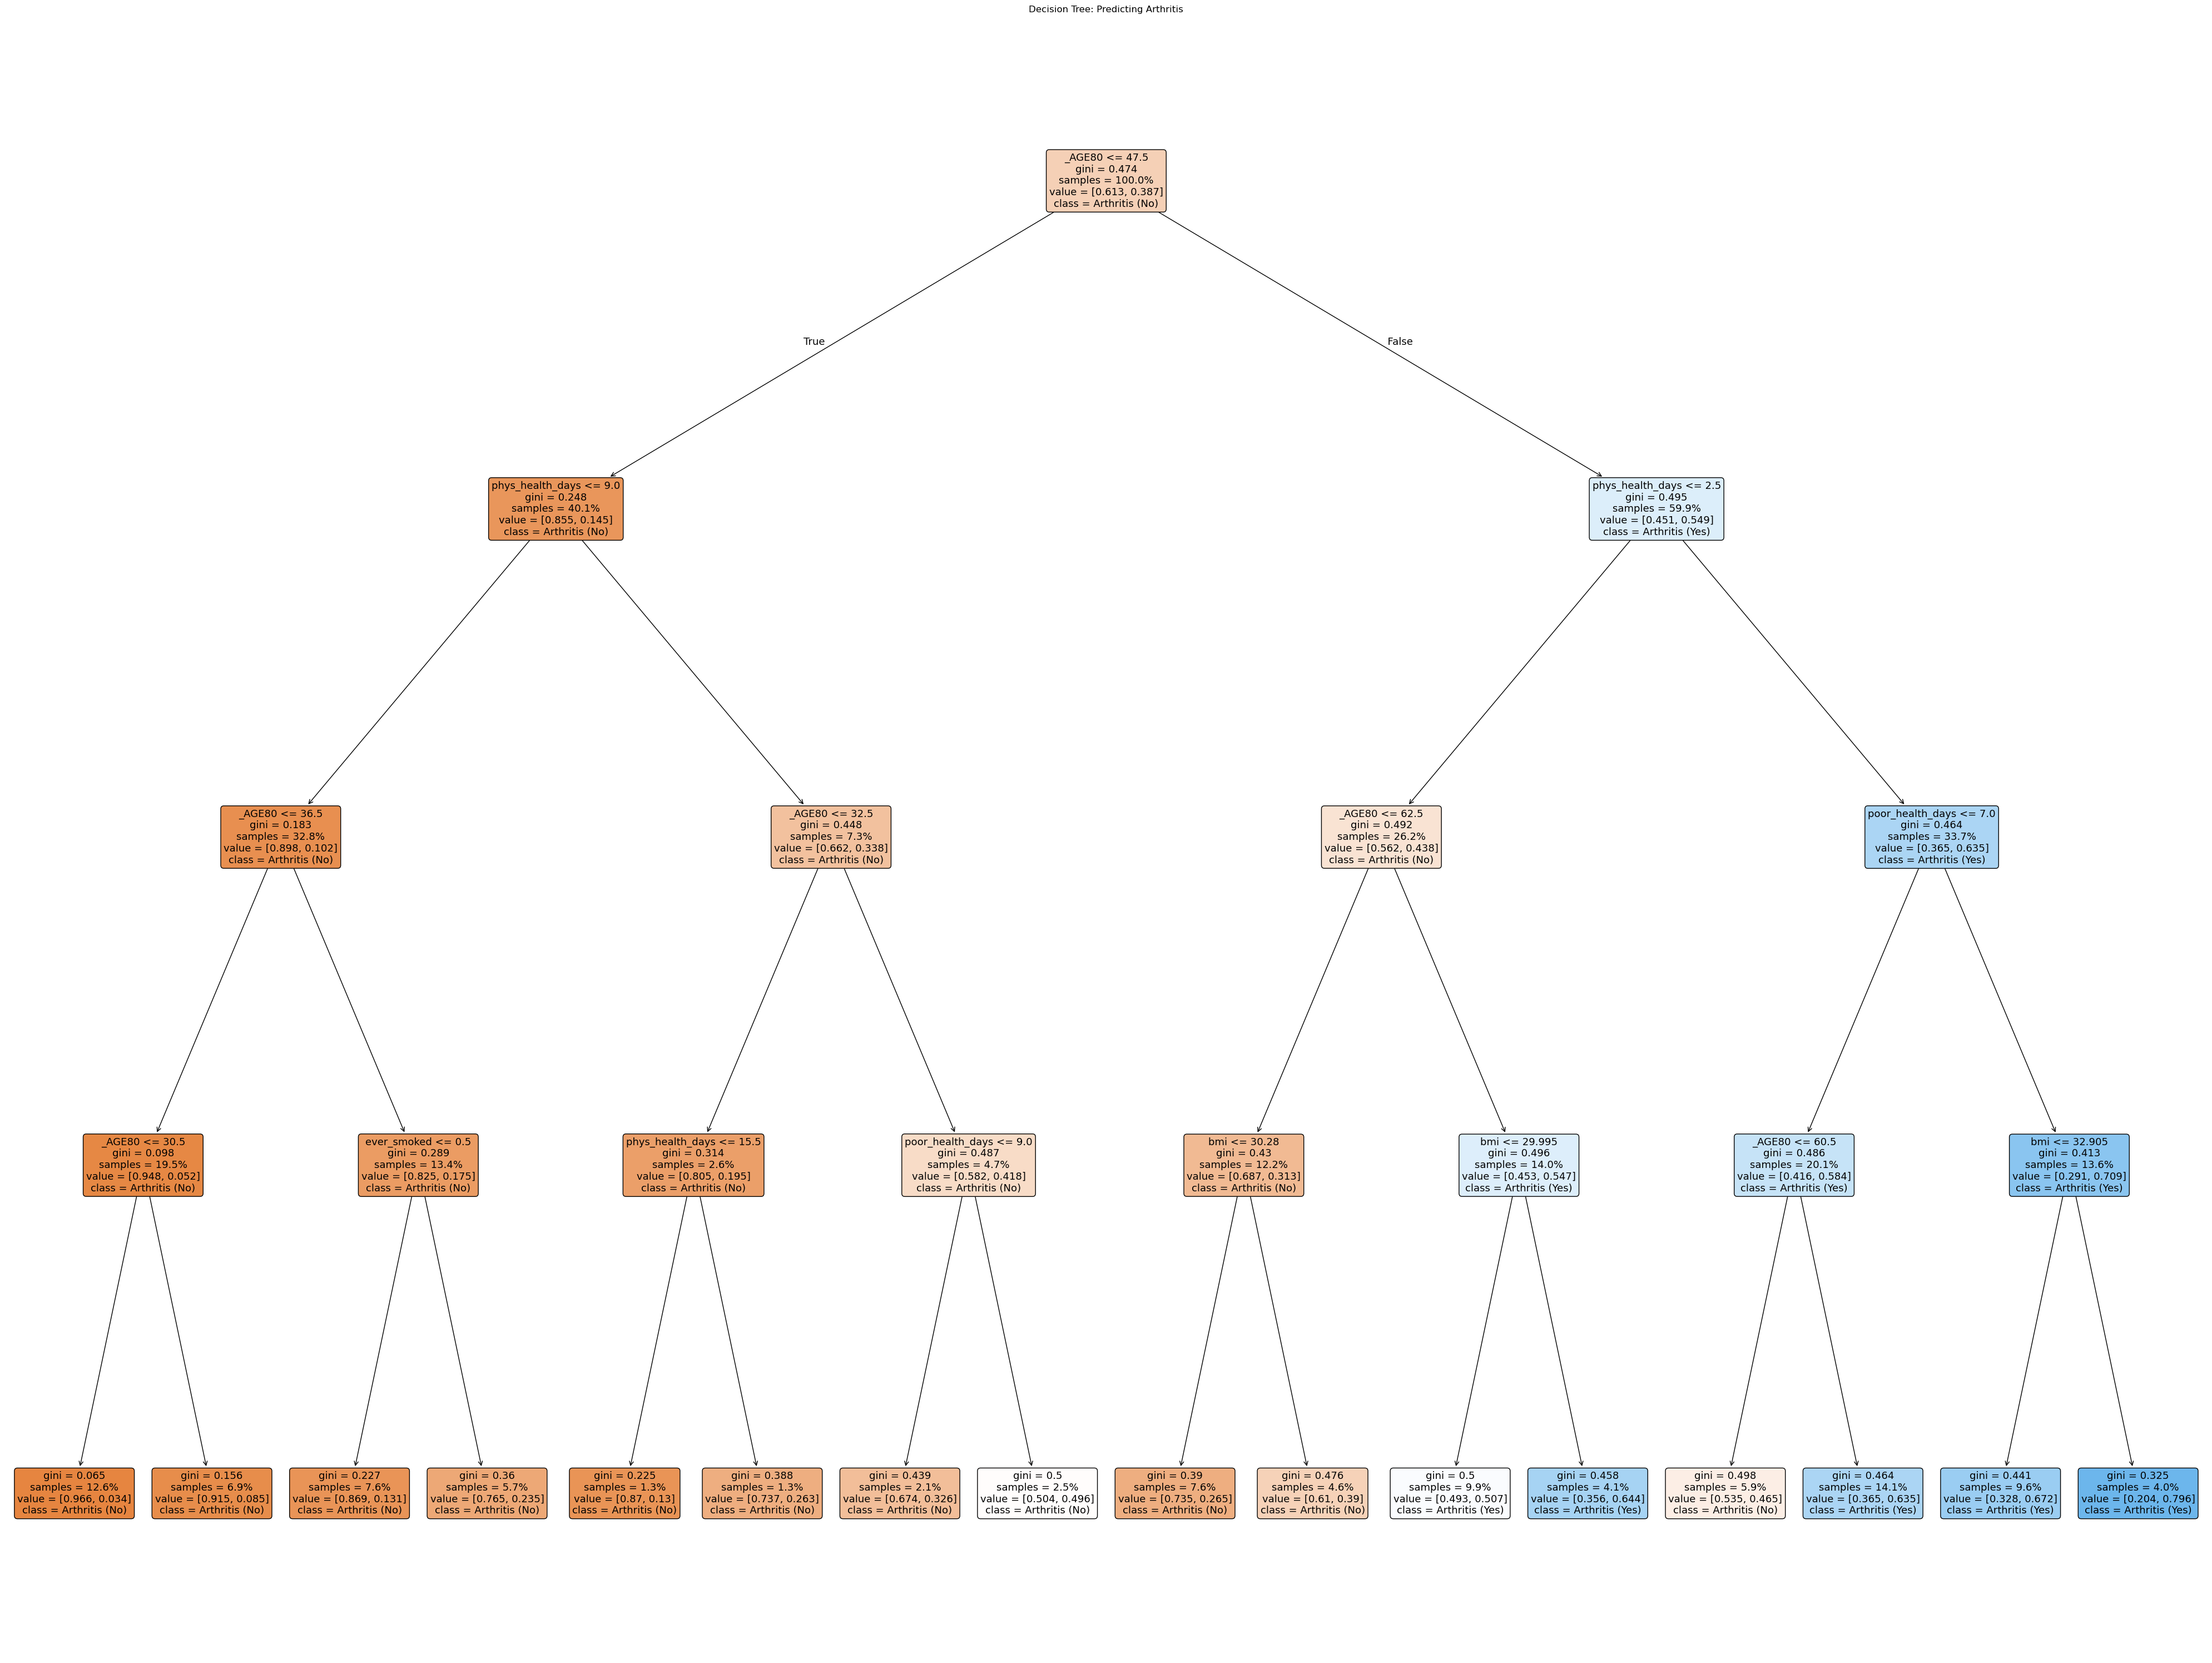

In [31]:
import matplotlib.pyplot as plt

feature_names = ['bmi', '_AGE80', 'ever_smoked', 'phys_health_days', 'poor_health_days', 'has_health_plan', 'EDUCA', '_SEX']

#Plot the decision tree
plt.figure(figsize=(40, 30))
plot_tree(tree_model, 
          feature_names=feature_names,
          class_names=['Arthritis (No)', 'Arthritis (Yes)'],
          filled=True, 
          rounded=True,
          proportion=True,
          fontsize=13)
plt.title('Decision Tree: Predicting Arthritis')
plt.tight_layout()
plt.show()

## PART 4: Synthesis & Comparison (Week 5)

### Question #3: Logistic Regression vs Classification Tree (3 marks each, 12 marks)

Compare the logistic regression (Task #6) and classification tree (Task #7) models for predicting arthritis:

a) Which model achieved better performance on the test set? Compare their accuracy, precision, and recall. 

b) Looking at the features that are important from the decision tree (Task #7b) and the odds ratios from logistic regression (Task #6b), do both models agree on which features are important for predicting arthritis? Explain. 

c) What is one advantage of using a decision tree over logistic regression for this arthritis prediction task? What is one advantage of logistic regression over a decision tree?

d) Briefly describe a set of characteristics (e.g., BMI, smoking, etc.) of a person in the dataset who is predicted to not have arthritis using the tree diagram.  Briefly explain. 

**Answer #3:**


*(a) Model performance comparison*
- Logistic regression accuracy ≈ 0.73
- Decision tree accuracy ≈ 0.72
- Logistic regression has higher precision
- Decision tree has higher recall (≈ 0.7 vs ≈ 0.6 for logistic regression)
- Interpretation:
    - Higher precision → fewer false positives
    - Higher recall → fewer false negatives (catches more arthritis cases)
- Conclusion (important for full marks):
Although logistic regression has slightly better accuracy and precision, the decision tree may be preferred in a public health setting because its higher recall means fewer missed arthritis cases. The tradeoff is lower precision (more false positives), but in screening settings this is often acceptable because it is more important to identify potential cases than to miss them. Full marks should especially reward answers that recognize the public health relevance of higher recall.

*(b) Feature importance comparison*
- Decision tree splits mainly on age and physical health days
- Logistic regression shows features like health plan, sex, or similar variables with high odds ratios
- Models do not fully agree on most important predictors
- Explanation: Decision trees determine importance based on how well variables split the data at each node. Logistic regression measures the overall effect of each predictor on the odds of arthritis.
- Full marks require: 
    - Mention of important features from both models
    - Clear statement that they differ
    - Explanation of why importance differs between modeling approaches

*(c) Advantages of each model*
- Preferred advantages of decision tree:
    - Captures non-linear relationships
    - Automatically models interaction effects
    - Higher recall is beneficial in screening contexts
    - Note: Visual interpretability alone should not be considered the strongest advantage.
- Preferred advantages of logistic regression:
    - Provides interpretable odds ratios
    - Clear quantification of predictor effects
    - Often more stable and slightly higher precision/accuracy
    - Full marks require one correct, well-explained advantage for each model.

*(d) Tree prediction path*
- Example path predicting no arthritis:
    - Age ≤ threshold (e.g., 47.5)
    - Physical health days ≤ threshold
    - Further age splits leading to non-arthritis leaf
- Explanation: younger individuals with fewer poor health days are predicted not to have arthritis.
Full marks are given if you mention the correct sequence of split conditions (a path that ends in a “no arthritis” leaf) and include a brief explanation connecting characteristics to prediction.
